# 3. A Rede de Monitoramento Brasileira


<div style="text-align: justify">No presente relatório, foram contabilizadas <b>570 estações de monitoramento da qualidade do ar no Brasil</b>, um aumento de 91 unidades em relação ao relatório com ano base 2023. Do total de estações em 2024, <b>367 utilizam método de referência ou equivalente</b>, indicando redução de 18 unidades em comparação ao levantamento anterior. As <b>estações indicativas somam 194</b>, um aumento de 100 unidades frente a 2023, enquanto em <b>9 estações o método de monitoramento não foi informado pela UF. </b></div><br/>

<div style="text-align: justify">Quanto ao status de funcionamento, as <b>estações de referência somam 280 ativas, 68 inativas e 18 sem declaração de status.</b> Entre as <b>indicativas, 190 estão ativas, 1 inativa e 3 sem informação</b>, enquanto no grupo com <b>método não declarado há 4 estações ativas e 5 inativas.</b>  </div><br/>

<div style="text-align: justify">Assim, no conjunto da rede em 2024, <b>474 estações estavam ativas, 75 inativas e 21 não tiveram seu status informado,</b> o que reflete também limitações no envio de dados por parte dos estados.</div><br/>

<div style="text-align: justify">Cabe ressaltar que os acréscimos e reduções observados em comparação a 2023 nem sempre correspondem à instalação ou desativação de estações no período. Em muitos casos, podem estar associados a falhas de reporte pelas UFs, de modo que parte das estações contabilizadas em 2024 podem não terem sido informadas em levantamentos anteriores.</div><br/>

<div style="text-align: justify">Os números reportados acima referem-se às instalações físicas com infraestrutura para abrigar os equipamentos de medição das concentrações de poluentes. Desta forma, destaca-se que uma mesma estação de monitoramento pode medir, simultaneamente, múltiplos poluentes. </div>

<div style="text-align: justify">Neste caso, nas seguintes seções do relatório, alguns resultados são organizados e discutidos de acordo com o número de pontos de monitoramento disponíveis para cada poluente específico. </div>

```{note}
É importante destacar que as estações indicativas são integradas em plataformas internacionais com finalidade científica, exploratória e informativa. A gestão dos dados ocorre por meio da integração dos equipamentos na plataforma. Em alguns casos, a operação e supervisão é realizada pelos OEMAs. <br/>

Estas estações são equipadas com instrumentos e sensores não considerados equivalentes às estações de referência. As estações indicativas são capazes de monitorar a concentração de alguns poluentes atmosféricos em tempo real, no entanto, podem apresentar um grau de incerteza relevante em relação ao dado gerado, principalmente quando não são calibradas e operadas adequadamente.
```

<div style="text-align: justify">É importante ressaltar que as estações indicativas não atendem aos critérios estabelecidos pelo Guia Técnico para o Monitoramento e Avaliação da Qualidade do Ar <cite id="ip3dh"><a href="#zotero%7C22267313%2FM8BLF2PV">(BRASIL, 2020)</a></cite>, mas podem fornecer informações relevantes sobre a qualidade do ar, principalmente em locais sem nenhuma estação de referência ou equivalente.</div>

```{note}
As estações sem registro de início e fim de operação foram contabilizadas apenas nos anos de 2023 e 2024. Alguns períodos de operação foram estimados a partir da data de instalação e operação.
```

<div style="text-align: justify">As Figuras 20, 21 e 22 mostram, respectivamente, a evolução do número de estações de monitoramento em cada UF no Brasil, variação anual de estações na rede estadual, e o número de pontos de monitoramento por poluente que foram registrados na base de dados desenvolvida neste relatório. Na Figura 22 foram considerados apenas os pontos de monitoramento que possuem registro de início e fim de operação. Em todos os casos, foram contabilizadas apenas estações ativas no ano vigente. </div>
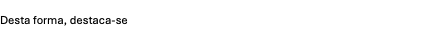
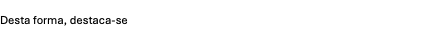
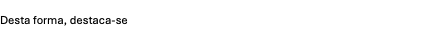
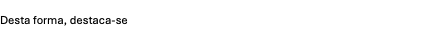

```{tip}
Nas Figuras 20 e 21, escolha um estado na barra lateral à direita para filtrar a figura e visualizar seus dados ao longo dos anos. Nos botões na parte superior, selecione a categoria de estação desejada.
```

In [3]:
# -*- coding: utf-8 -*-
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import os
from IPython.display import HTML, display
from matplotlib import colormaps as m_colormaps
from matplotlib import colors as mcolors

# ===========================
# 1. Caminhos e Leitura
# ===========================
rootPath = os.path.dirname(os.getcwd())
aqm_path = os.path.join(rootPath, "data", "Monitoramento_QAr_BR.csv")

try:
    aqmData = pd.read_csv(aqm_path)
except FileNotFoundError:
    try:
        aqmData = pd.read_csv("Monitoramento_QAr_BR.csv")
    except FileNotFoundError:
        # Cria dataframe vazio se falhar, apenas para não quebrar o script de exemplo
        aqmData = pd.DataFrame(columns=['ID_OEMA', 'UF', 'CATEGORIA', 'STATUS', 'ANOS_MONITORADOS'])

# ===========================
# 2. Lógica de Dados
# ===========================

# --- CORREÇÃO PRINCIPAL AQUI ---
# 1. Primeiro removemos espaços do ID para garantir que "SP 001" seja igual a "SP001"
aqmData['ID_OEMA'] = aqmData['ID_OEMA'].astype(str).str.replace(' ', '')

# 2. Agora sim removemos duplicadas
aqmData = aqmData.drop_duplicates(subset=['ID_OEMA'])

# 2.2. Parse dos Anos
def parse_anos(x):
    try:
        return [
            int(z) for z in str(x)
            .replace('[','').replace(']','').replace("'",'').replace(" ",'')
            .split(',') if z.strip().isdigit()
        ]
    except:
        return []

aqmData['ANOS_MONITORADOS'] = aqmData['ANOS_MONITORADOS'].apply(parse_anos)

# 2.3. Padronizar Status
if 'STATUS' not in aqmData.columns:
    aqmData['STATUS'] = 'Não declarado'
aqmData['STATUS'] = aqmData['STATUS'].fillna('Não declarado').astype(str).str.strip().str.lower()

# 2.4. Filtro: ATIVA ou TEM 2024
def has_2024(lst):
    return isinstance(lst, list) and (2024 in lst)

def is_active(status):
    return status == "ativa"

aqmData['TEM_2024'] = aqmData['ANOS_MONITORADOS'].apply(has_2024)
mascara = aqmData['TEM_2024'] | aqmData['STATUS'].apply(is_active)
aqmData = aqmData[mascara].copy()

# 2.5. Injeção Visual de 2024 (Para Estações Ativas sem 2024 na lista)
ativas_sem_2024 = aqmData[(aqmData['STATUS']=="ativa") & (~aqmData['TEM_2024'])].copy()
if not ativas_sem_2024.empty:
    for idx in ativas_sem_2024.index:
        lista_atual = aqmData.at[idx, 'ANOS_MONITORADOS']
        if isinstance(lista_atual, list):
             aqmData.at[idx, 'ANOS_MONITORADOS'] = lista_atual + [2024]

# 2.6. Padronização de Categorias
col_target = 'CATEGORIA'
if col_target not in aqmData.columns:
    aqmData[col_target] = 'Não declarado'

aqmData[col_target] = aqmData[col_target].fillna('Não declarado').astype(str).str.strip().str.capitalize()

correction_map = {
    'Referencia': 'Referência',
    'Referência': 'Referência',
    'Indicativa': 'Indicativa',
    'Nao declarado': 'Não declarado',
    'Não declarado': 'Não declarado',
    'Nao declarada': 'Não declarado',
    'Não declarada': 'Não declarado'
}
aqmData[col_target] = aqmData[col_target].replace(correction_map)

# Garante apenas as categorias válidas
valid_cats = ['Referência', 'Indicativa', 'Não declarado']
aqmData.loc[~aqmData[col_target].isin(valid_cats), col_target] = 'Não declarado'

# ===========================
# 3. Explode e Agregação
# ===========================
df_exploded = aqmData.explode("ANOS_MONITORADOS")
df_exploded = df_exploded.dropna(subset=['ANOS_MONITORADOS'])
df_exploded['ANOS_MONITORADOS'] = df_exploded['ANOS_MONITORADOS'].astype(int)

# Filtra até 2024 e remove duplicatas (caso a injeção tenha criado "2024, 2024")
df_exploded = df_exploded[df_exploded['ANOS_MONITORADOS'] <= 2024]
df_exploded = df_exploded.drop_duplicates(subset=['ID_OEMA', 'ANOS_MONITORADOS'])

df_counts = (
    df_exploded.groupby(['ANOS_MONITORADOS', 'UF', 'CATEGORIA'])['ID_OEMA']
    .nunique()
    .reset_index(name='Num_Stations')
)

anos = sorted(df_counts['ANOS_MONITORADOS'].unique())
ufs = sorted(df_counts['UF'].unique())
categorias = ['Referência', 'Indicativa', 'Não declarado']

# ===========================
# 4. Cores e Layout
# ===========================
n_colors = len(ufs)
cmap = m_colormaps['gist_ncar']
sample_points = np.linspace(0, 1, n_colors)
color_sequence = [mcolors.rgb2hex(cmap(i)) for i in sample_points]
color_map = {uf: color_sequence[i] for i, uf in enumerate(ufs)}

fig_bars = go.Figure()

visibility_all = []
visibility_ref = []
visibility_ind = []
visibility_nd = []

for uf in ufs:
    df_uf_total = df_counts[df_counts['UF'] == uf]
    show_legend_uf = True 
    
    for cat in categorias:
        df_plot = df_uf_total[df_uf_total['CATEGORIA'] == cat].sort_values('ANOS_MONITORADOS')
        
        if not df_plot.empty:
            # Melhoria no Hover: Removemos a repetição do nome do Estado e Ano, pois o 'unified' já mostra
            # Mas se preferir ver no box individual, o formato abaixo é limpo:
            custom_hover = (
                f"<b>Tipo: {cat}</b><br>" +
                f"Qtd: %{{y}}" +
                "<extra></extra>" # Remove a caixa lateral padrão do Plotly
            )
            
            fig_bars.add_trace(go.Bar(
                x=df_plot['ANOS_MONITORADOS'],
                y=df_plot['Num_Stations'],
                name=uf, 
                legendgroup=uf, 
                showlegend=show_legend_uf,
                marker_color=color_map[uf],
                customdata=[cat] * len(df_plot),
                hovertemplate=custom_hover
            ))
            
            show_legend_uf = False 
            
            visibility_all.append(True)
            visibility_ref.append(True if cat == 'Referência' else False)
            visibility_ind.append(True if cat == 'Indicativa' else False)
            visibility_nd.append(True if cat == 'Não declarado' else False)

# ===========================
# 6. Botões e Layout
# ===========================
updatemenus = [
    dict(
        type="buttons",
        direction="left",
        pad={"r": 10, "t": 10},
        showactive=True,
        x=0.0,
        xanchor="left",
        y=1.15,
        yanchor="top",
        buttons=list([
            dict(label="Todas", method="update", 
                 args=[{"visible": visibility_all}, {"title": ""}]),
            dict(label="Referência", method="update", 
                 args=[{"visible": visibility_ref}, {"title": ""}]),
            dict(label="Indicativa", method="update", 
                 args=[{"visible": visibility_ind}, {"title": ""}]),
            dict(label="Não Declarado", method="update", 
                 args=[{"visible": visibility_nd}, {"title": ""}]),
        ]),
    )
]

layout_style = dict(
    plot_bgcolor="whitesmoke",
    paper_bgcolor="white",
    hovermode='x unified', # Unifica o hover por Ano
    legend_title="UF",
    height=650,
    updatemenus=updatemenus
)

fig_bars.update_layout(
    **layout_style,
    barmode='stack',
    xaxis_title="Ano",
    yaxis_title="Número de pontos de monitoramento",
    xaxis=dict(type='linear', tickmode='array', tickvals=anos, ticktext=anos)
)

# ===========================
# 7. Exportar
# ===========================
html_path = os.path.join(rootPath, "_static", "monitoramento", "fig_num_pontos_UF_interactive.html")
#os.makedirs(os.path.dirname(html_path), exist_ok=True) # Descomente se precisar criar pasta
fig_bars.write_html(html_path, include_plotlyjs="cdn")

display(HTML(fig_bars.to_html(include_plotlyjs="cdn")))

<p style="text-align:center; color:#636D7D; font-size:15.5px;">
  <em>Fig. 20</em> Número de estações de monitoramento por UF.
</p>

In [2]:
# -*- coding: utf-8 -*-
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import numpy as np
import os
from IPython.display import HTML
# from IPython.display import HTML # Removido para compatibilidade com o ambiente

# Importa módulos Matplotlib para a paleta de 27 cores
from matplotlib import colormaps as m_colormaps 
from matplotlib import colors as mcolors 

# ===========================
# 1. Caminhos e Leitura (REVERTIDO PARA LÓGICA DE CWD)
# ===========================
rootPath = os.path.dirname(os.getcwd())
aqm_path = os.path.join(rootPath, "data", "Monitoramento_QAr_BR.csv")
try:
    # 1. Tenta o caminho original (baseado no diretório de trabalho)
    aqmData = pd.read_csv(aqm_path)
except:
    # 2. Se falhar, tenta ler o arquivo diretamente do diretório atual
    aqmData = pd.read_csv("Monitoramento_QAr_BR.csv")
    
# Limpeza e Padronização
# ===========================
# FILTRAR SOMENTE ESTAÇÕES QUE MONITORARAM EM 2024
# ===========================

def parse_anos(x):
    try:
        return [int(z) for z in str(x)
                .replace('[','').replace(']','').replace("'",'')
                .split(',') if z.strip().isdigit()]
    except:
        return []

aqmData['ANOS_MONITORADOS'] = aqmData['ANOS_MONITORADOS'].apply(parse_anos)

# Filtro dos dados para apenas as estações que possuem 2024
aqmData = aqmData[aqmData['ANOS_MONITORADOS'].apply(lambda lst: 2024 in lst)]

# Remover duplicidades agora garante coerência
aqmData = aqmData.drop_duplicates(subset=['ID_OEMA'])

if 'CATEGORIA' not in aqmData.columns:
    aqmData['CATEGORIA'] = 'Não declarado'

aqmData['CATEGORIA'] = aqmData['CATEGORIA'].fillna('Não declarado').astype(str).str.strip().str.capitalize()
correction_map = {
    'Referencia': 'Referência', 'Indicativa': 'Indicativa',
    'Nao declarado': 'Não declarado', 'Nao declarada': 'Não declarado', 'Não declarada': 'Não declarado'
}
aqmData['CATEGORIA'] = aqmData['CATEGORIA'].replace(correction_map)
valid_cats = ['Referência', 'Indicativa', 'Não declarado']
aqmData.loc[~aqmData['CATEGORIA'].isin(valid_cats), 'CATEGORIA'] = 'Não declarado'

# Tratamento de Anos
if aqmData["ANOS_MONITORADOS"].dtype == object:
    aqmData["ANOS_MONITORADOS"] = aqmData["ANOS_MONITORADOS"].apply(
        lambda x: [int(y) for y in str(x)
                   .replace("[","").replace("]","").replace("'", "")
                   .split(",") if y.strip().isdigit()]
    )

df_exploded = aqmData.explode("ANOS_MONITORADOS")
df_exploded = df_exploded.dropna(subset=['ANOS_MONITORADOS'])
df_exploded['ANOS_MONITORADOS'] = df_exploded['ANOS_MONITORADOS'].astype(int)

# ===========================
# 2. Agregação para Diferença
# ===========================
df_total = (
    df_exploded.groupby(['ANOS_MONITORADOS', 'UF'])['ID_OEMA']
    .nunique().reset_index(name='Num_Stations')
)
df_total['CATEGORIA'] = 'Total'

df_by_cat = (
    df_exploded.groupby(['ANOS_MONITORADOS', 'UF', 'CATEGORIA'])['ID_OEMA']
    .nunique().reset_index(name='Num_Stations')
)

df_combined = pd.concat([df_total, df_by_cat])
df_combined = df_combined[df_combined['ANOS_MONITORADOS'] <= 2024]

anos = sorted(df_combined['ANOS_MONITORADOS'].unique())
ufs = sorted(df_combined['UF'].unique())

# ===========================
# 3. Cores (APLICANDO PALETA MATPLOTLIB)
# ===========================
n_colors = len(ufs)

# OBTENDO O COLORMAP 'gist_ncar' DE FORMA MODERNA
cmap = m_colormaps['gist_ncar'] 

# Gera n_colors pontos linearmente espaçados no colormap
sample_points = np.linspace(0, 1, n_colors) 

# Converte as cores RGB do Matplotlib para o formato Hex (Plotly)
color_sequence = [mcolors.rgb2hex(cmap(i)) for i in sample_points]

# Cria o dicionário UF -> Cor
color_map = {}
for i, uf in enumerate(ufs):
    color_map[uf] = color_sequence[i]

# ===========================
# 4. Construção do Gráfico
# ===========================
fig_diff = go.Figure()

# Listas de Controle (Booleanas)
vis_total = []
vis_ref = []
vis_ind = []
vis_nd = []

all_diffs = []
scenarios = ['Total', 'Referência', 'Indicativa', 'Não declarado']

for uf in ufs:
    for scenario in scenarios:
        # Filtra dados
        mask = (df_combined['UF'] == uf) & (df_combined['CATEGORIA'] == scenario)
        df_uf = df_combined[mask].sort_values('ANOS_MONITORADOS')
        
        # Preenche com 0 para o cálculo de diferença anual
        if df_uf.empty:
            x_data = []
            y_data = []
            diff_list = []
        else:
            df_uf = df_uf.set_index('ANOS_MONITORADOS').reindex(anos, fill_value=0).reset_index()
            # Calcula a diferença anual
            df_uf['Difference'] = df_uf['Num_Stations'].diff().fillna(0)
            x_data = df_uf['ANOS_MONITORADOS']
            y_data = df_uf['Difference']
            diff_list = df_uf['Difference'].tolist()
        
        all_diffs.extend(diff_list)

        # Define estado INICIAL (apenas Total visível e com legenda)
        is_total = (scenario == 'Total')
        is_ref = (scenario == 'Referência')
        is_ind = (scenario == 'Indicativa')
        is_nd = (scenario == 'Não declarado')

        fig_diff.add_trace(go.Scatter(
            x=x_data,
            y=y_data,
            mode='lines+markers',
            name=uf,
            legendgroup=uf, # Agrupa todos deste estado
            showlegend=is_total, # Inicialmente, só o Total gera legenda
            visible=is_total,    # Inicialmente, só o Total é visível
            line=dict(color=color_map[uf]), 
            marker=dict(color=color_map[uf]),
            hovertemplate=f"<b>{uf}</b> ({scenario})<br>Ano: %{{x}}<br>Diferença: %{{y}}<extra></extra>"
        ))
        
        # Popula as listas para os botões (para visibilidade e legenda)
        vis_total.append(is_total)
        vis_ref.append(is_ref)
        vis_ind.append(is_ind)
        vis_nd.append(is_nd)


# ===========================
# 5. Configuração dos Botões
# ===========================
updatemenus = [
    dict(
        type="buttons",
        direction="left",
        pad={"r": 10, "t": 10},
        showactive=True,
        x=0.0,
        xanchor="left",
        y=1.15,
        yanchor="top",
        buttons=list([
            dict(
                label="Geral", 
                method="update", 
                args=[
                    {"visible": vis_total, "showlegend": vis_total}, 
                    {"title": ""}
                ]
            ),
            dict(
                label="Referência", 
                method="update", 
                args=[
                    {"visible": vis_ref, "showlegend": vis_ref}, 
                    {"title": ""}
                ]
            ),
            dict(
                label="Indicativa", 
                method="update", 
                args=[
                    {"visible": vis_ind, "showlegend": vis_ind}, 
                    {"title": ""}
                ]
            ),
            dict(
                label="Não Declarado", 
                method="update", 
                args=[
                    {"visible": vis_nd, "showlegend": vis_nd}, 
                    {"title": ""}
                ]
            ),

        ]),
    )
]

# ===========================
# 6. Layout e Exportação
# ===========================
if all_diffs:
    max_val = max(all_diffs)
    min_val = min(all_diffs)
    # Define o range do eixo Y baseado no maior valor absoluto (para centralizar em zero)
    max_abs_value = max(abs(max_val), abs(min_val))
else:
    max_abs_value = 10

layout_style = dict(

    plot_bgcolor="white",
    paper_bgcolor="white",
    hovermode='x unified',
    legend_title="UF",
    height=800,
    updatemenus=updatemenus
)

fig_diff.update_layout(
    **layout_style,
    xaxis_title="Ano",
    yaxis_title="Diferença anual",
    xaxis_range=[min(anos) - 0.5, 2024.5],
    xaxis=dict(
        type='linear',
        title="Ano",
        tickmode='array',
        tickvals=anos,
        ticktext=anos
    ),
    yaxis_range=[-max_abs_value * 1.1, max_abs_value * 1.1], # Aplica o range centralizado
    shapes=[
        # Zona de redução (abaixo de zero)
        dict(type="rect", xref="paper", x0=0, x1=1, yref="y", y0=-max_abs_value * 1.1, y1=0,  
             fillcolor="mistyrose", opacity=0.5, layer="below", line_width=0),
        # Zona de crescimento (acima de zero)
        dict(type="rect", xref="paper", x0=0, x1=1, yref="y", y0=max_abs_value * 1.1, y1=0,  
             fillcolor="lightblue", opacity=0.5, layer="below", line_width=0),
        # Linha zero central
        dict(type="line", xref="paper", x0=0, x1=1, yref="y", y0=0, y1=0,
             line=dict(color="gray", width=2), layer="below")
    ]
)

html_path = os.path.join(rootPath, "_static", "monitoramento", "fig_diff_UF_interactive.html")
os.makedirs(os.path.dirname(html_path), exist_ok=True)
fig_diff.write_html(html_path, include_plotlyjs="cdn")

display(HTML(fig_diff.to_html(include_plotlyjs="cdn")))

<p style="text-align:center; color:#636D7D; font-size:15.5px;">
  <em>Fig. 21</em> Acréscimo e decréscimo anual do número de estações de monitoramento por UF.
</p>

```{tip}
Selecione o poluente no dropdown menu e avalie a evolução do número de pontos de monitoramento. Clique na legenda para controlar os estados que agregam estações na figura.   
```

In [4]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import HTML

# ================================
# 1. Carregar e preparar dados
# ================================
rootPath = os.path.dirname(os.getcwd())
aqm_path = os.path.join(rootPath, "data", "Monitoramento_QAr_BR.csv")

df = pd.read_csv(aqm_path)

# UF sem espaços
df["UF"] = df["UF"].astype(str).str.replace(" ", "")

# PM25 -> MP25 (como no seu código)
df.loc[df["POLUENTE"] == "PM25", "POLUENTE"] = "MP25"

# Tratamento de categorias
df["CATEGORIA"] = (
    df.get("CATEGORIA", "Não declarado")
      .fillna("Não declarado")
      .astype(str)
      .str.strip()
      .str.capitalize()
)

map_cat = {
    "Referencia": "Referência",
    "Indicativa": "Indicativa",
    "Nao declarado": "Não declarado",
    "Nao declarada": "Não declarado",
    "Não declarada": "Não declarado",
}
df["CATEGORIA"] = df["CATEGORIA"].replace(map_cat)

valid = ["Referência", "Indicativa", "Não declarado"]
df.loc[~df["CATEGORIA"].isin(valid), "CATEGORIA"] = "Não declarado"

# Anos monitorados: explode
df["ANOS_MONITORADOS"] = df["ANOS_MONITORADOS"].astype(str).str.split(",")
df = df.explode("ANOS_MONITORADOS")
df = df[pd.to_numeric(df["ANOS_MONITORADOS"], errors="coerce").notna()]
df["ANOS_MONITORADOS"] = df["ANOS_MONITORADOS"].astype(int)

# Se quiser, limite até 2024
df = df[df["ANOS_MONITORADOS"] <= 2024]

# Agrupamento: POLUENTE / UF / CATEGORIA / ANO
df_ag = (
    df.groupby(["POLUENTE", "UF", "CATEGORIA", "ANOS_MONITORADOS"])
      .size()
      .reset_index(name="NSTATION")
)

# Renomear coluna de ano pra facilitar no JS
df_ag = df_ag.rename(columns={"ANOS_MONITORADOS": "ANO"})

# ================================
# 2. Cores por UF (MESMAS DO ALTAIR)
# ================================
ufs = sorted(df_ag["UF"].unique())
n_colors = len(ufs)

cmap = plt.get_cmap("gist_ncar")
sample_points = np.linspace(0, 1, n_colors)
color_sequence = [mcolors.to_hex(cmap(i)) for i in sample_points]

uf_colors = {uf: color_sequence[i] for i, uf in enumerate(ufs)}

# ================================
# 3. Dados → JSON para o JS
# ================================
rows = df_ag.to_dict(orient="records")
json_data = json.dumps(rows, ensure_ascii=False)
uf_colors_json = json.dumps(uf_colors, ensure_ascii=False)

# ================================
# 4. Template HTML + JS (Plotly)
# ================================
html_template = r"""
<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8"/>
<script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
<style>
body {
  font-family: Arial, sans-serif;
  margin: 0;
  padding: 14px;
  background: #fff;
}
#controls {
  display: flex;
  flex-wrap: wrap;
  gap: 16px;
  align-items: center;
  margin-bottom: 10px;
}
.control {
  display: flex;
  align-items: center;
  gap: 6px;
}
.label {
  font-size: 14px;
  font-weight: 600;
  color: #333;
  white-space: nowrap;
}
.select {
  appearance: none;
  padding: 4px 8px;
  border: 1px solid #999;
  border-radius: 4px;
  background: #f9f9f9;
  cursor: pointer;
  font-size: 13px;
}
#figMonitor {
  width: 100%;
  height: 650px;
}
</style>
</head>

<body>

<div id="controls">
  <div class="control">
    <span class="label">Poluente:</span>
    <select id="selPol" class="select"></select>
  </div>

  <div class="control">
    <span class="label">Categoria:</span>
    <select id="selCat" class="select"></select>
  </div>
</div>

<div id="figMonitor"></div>

<script>
const DATA = __DATA__;
const UF_COLORS = __UF_COLORS__;

// ===== Preenche dropdowns =====
const selPol = document.getElementById("selPol");
const selCat = document.getElementById("selCat");

function uniqueSorted(arr) {
  return Array.from(new Set(arr)).sort();
}

// Poluentes
const poluentes = uniqueSorted(DATA.map(d => d.POLUENTE));
poluentes.forEach(p => {
  const opt = document.createElement("option");
  opt.value = p;
  opt.textContent = p;
  selPol.appendChild(opt);
});

// Categorias
const categorias = uniqueSorted(DATA.map(d => d.CATEGORIA));
selCat.appendChild(new Option("Todas", "Todas"));
categorias.forEach(c => {
  const opt = document.createElement("option");
  opt.value = c;
  opt.textContent = c;
  selCat.appendChild(opt);
});

// Valores padrão
if (poluentes.includes("MP25")) {
  selPol.value = "MP25";
}

// ===== Atualizar gráfico =====
function updatePlot() {
  const pol = selPol.value;
  const cat = selCat.value;

  // Filtrar dados
  const filtered = DATA.filter(d =>
    d.POLUENTE === pol &&
    (cat === "Todas" || d.CATEGORIA === cat)
  );

  if (filtered.length === 0) {
    Plotly.newPlot("figMonitor", [], {
      title: {text: "Sem dados para o filtro selecionado", x: 0.5}
    });
    return;
  }

  // Anos e UFs
  const anos = uniqueSorted(filtered.map(d => d.ANO)).map(Number);
  const ufs = uniqueSorted(filtered.map(d => d.UF));

  const traces = ufs.map(uf => {
    const ys = anos.map(ano => {
      return filtered
        .filter(d => d.UF === uf && Number(d.ANO) === ano)
        .reduce((acc, d) => acc + Number(d.NSTATION || 0), 0);
    });
    return {
      type: "bar",
      name: uf,
      x: anos,
      y: ys,
      marker: { color: UF_COLORS[uf] || "#888888" },
      hovertemplate: "UF: " + uf + "<br>Ano: %{x}<br>N. pontos: %{y}<extra></extra>"
    };
  });

  const layout = {
    barmode: "stack",
    template: "plotly_white",
    title: {
      text: "",
      x: 0.5
    },
    xaxis: {
      title: "Ano",
      dtick: 1
    },
    yaxis: {
      title: "N. pontos de monitoramento"
    },
    legend: {
      orientation: "h",
      yanchor: "bottom",
      y: -0.25,
      xanchor: "left",
      x: 0,
      title: { text: "UF" }
    },
    margin: { l: 60, r: 20, t: 60, b: 80 },
    hovermode: "x unified",
    hoverlabel: {
      bgcolor: "white",
      bordercolor: "#444",
      font: { size: 11 }
    }
  };

  Plotly.newPlot("figMonitor", traces, layout, {displayModeBar: false});
}

// Eventos
selPol.addEventListener("change", updatePlot);
selCat.addEventListener("change", updatePlot);

// Plot inicial
updatePlot();
</script>

</body>
</html>
"""

# Substitui os placeholders pelo JSON de dados e cores
html_code = (
    html_template
    .replace("__DATA__", json_data)
    .replace("__UF_COLORS__", uf_colors_json)
)

HTML(html_code)


<p style="text-align:center; color:#636D7D; font-size:15.5px;">
  <em>Fig. 22</em> Número de pontos de monitoramento por poluente e UF. 
</p>

### Referências

<!-- BIBLIOGRAPHY END --><!-- BIBLIOGRAPHY START -->
<div class="csl-bib-body">
  <div class="csl-entry"><i id="zotero|22267313/M8BLF2PV"></i>BRASIL. <b>Guia Técnico para o Monitoramento e Avaliação da Qualidade do Ar</b>, 2020. </div>
</div>
<!-- BIBLIOGRAPHY END -->